# Notebook 2 - DBSCAN con scikit-learn (Implementacion Profesional)

**Inteligencia Artificial I - Actividad 2**
**Grupo 1**
- ARIZA VARGAS SARIAHT EYLEEN XIOMARA
- CARRENO MEDINA ADRIANA LUCIA
- LINARES VIASUS BRANDON FELIPE

---

## 1. Introduccion y Descripcion del Problema

### Problema a resolver
**Segmentacion de clientes** de un centro comercial usando DBSCAN para identificar
**grupos de comportamiento** (segun ingreso anual y spending score) y **detectar clientes
atipicos (outliers)** que requieren atencion individual.

### Por que es importante
La segmentacion permite a los equipos de marketing y CRM disenar campanas dirigidas,
optimizar promociones y detectar fraude o comportamiento anomalo. DBSCAN es ideal aqui
porque:
- No requiere conocer el numero de segmentos por adelantado.
- Detecta automaticamente clientes outliers (potenciales VIP o anomalias).
- Los clusters pueden tener cualquier forma (no asume distribuciones esfericas como K-Means).

### Descripcion del dataset
**Mall Customers** (estilo Kaggle - https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)
- 300 registros, 5 columnas: `CustomerID`, `Genre`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`
- Cumple el requisito de >= 100 registros para no supervisado.


## 2. Carga y Exploracion de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_csv("Mall_Customers.csv")
print("Forma:", df.shape)
df.head()

Forma: (300, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,62,21.50,30.22
1,2,Female,42,36.97,29.09
2,3,Male,34,15.00,11.51
3,4,Male,68,26.13,26.89
4,5,Male,30,21.86,26.99


In [2]:
print(df.info())
print("\nEstadisticas descriptivas:")
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              300 non-null    int64  
 1   Genre                   300 non-null    object 
 2   Age                     300 non-null    int64  
 3   Annual Income (k$)      300 non-null    float64
 4   Spending Score (1-100)  300 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 11.8+ KB
None

Estadisticas descriptivas:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,300.000000,300,300.000000,300.000000,300.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,152,NaN,NaN,NaN
mean,150.500000,NaN,42.376667,59.179700,51.846367
std,86.746758,NaN,15.179686,28.009297,27.932847
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,75.750000,NaN,30.000000,32.217500,25.075000
50%,150.500000,NaN,41.000000,57.730000,51.545000
75%,225.250000,NaN,56.000000,85.070000,78.457500


## 3. Analisis Exploratorio de Datos (EDA)

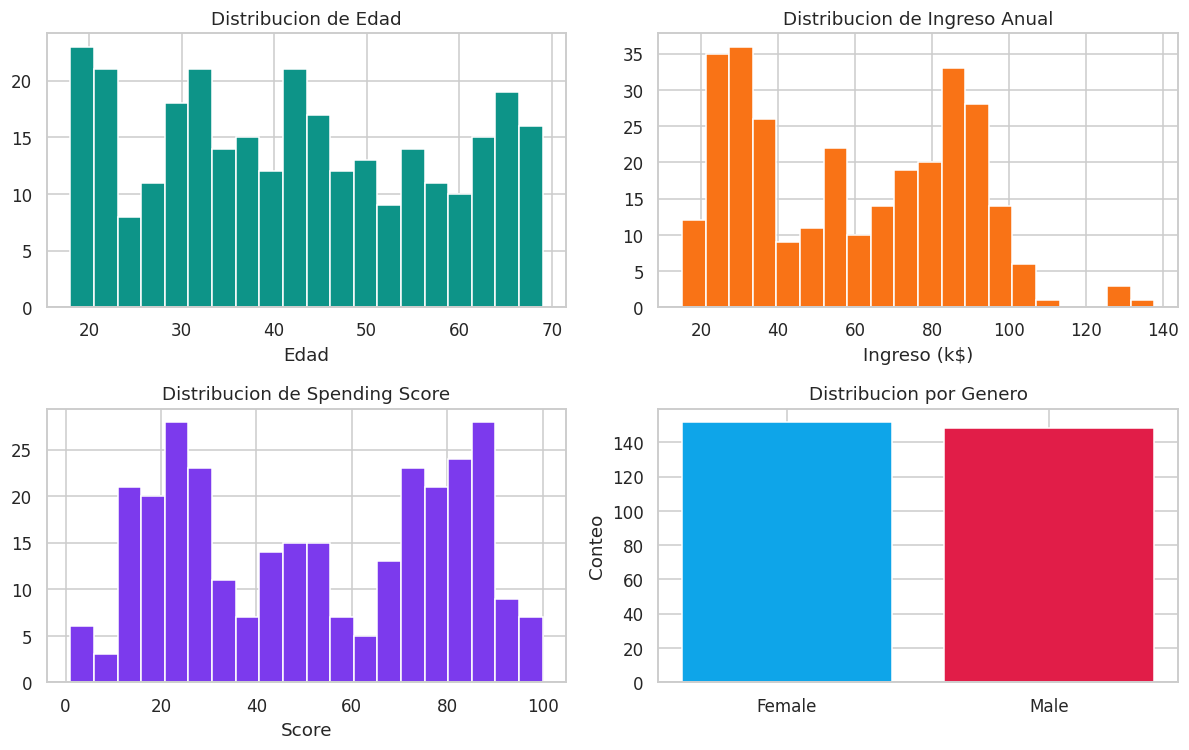

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].hist(df["Age"], bins=20, color="#0D9488", edgecolor="white")
axes[0, 0].set_title("Distribucion de Edad")
axes[0, 1].hist(df["Annual Income (k$)"], bins=20, color="#F97316", edgecolor="white")
axes[0, 1].set_title("Distribucion de Ingreso Anual")
axes[1, 0].hist(df["Spending Score (1-100)"], bins=20, color="#7C3AED", edgecolor="white")
axes[1, 0].set_title("Distribucion de Spending Score")
gc = df["Genre"].value_counts()
axes[1, 1].bar(gc.index, gc.values, color=["#0EA5E9", "#E11D48"])
axes[1, 1].set_title("Distribucion por Genero")
plt.tight_layout()
plt.show()

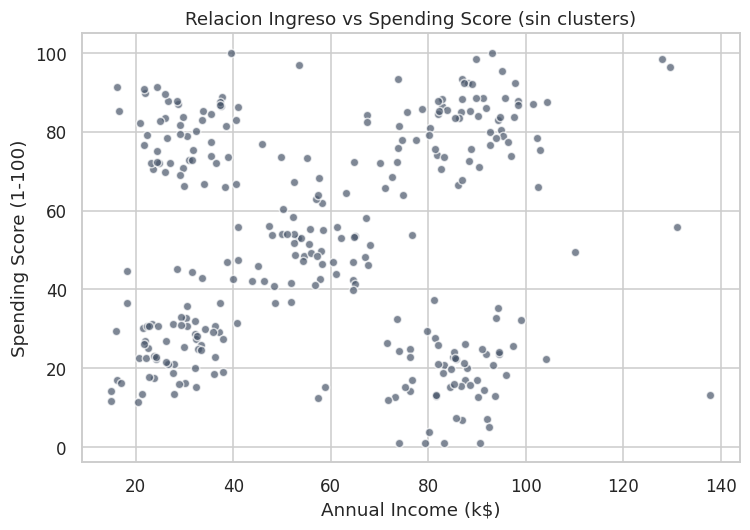

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
            c="#475569", s=30, alpha=0.7, edgecolor="white")
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.title("Relacion Ingreso vs Spending Score (sin clusters)")
plt.tight_layout(); plt.show()

## 4. Preprocesamiento

Para DBSCAN es **crucial estandarizar las variables** porque el algoritmo depende de
distancias euclidianas. Si las escalas son diferentes, las variables con mayor rango
dominan el calculo de vecindad.

In [5]:
from sklearn.preprocessing import StandardScaler

# Verificar valores nulos
print("Nulos por columna:\n", df.isna().sum())

# Seleccionar variables para clustering
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].values

# Estandarizacion (z-score)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print("\nForma X estandarizado:", X_std.shape)
print("Media:", X_std.mean(axis=0).round(4))
print("Std :", X_std.std(axis=0).round(4))

Nulos por columna:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Forma X estandarizado: (300, 2)
Media: [-0.  0.]
Std : [1. 1.]


### 4.1 Eleccion de hiperparametros (eps, min_samples)

Para escoger `eps` se usa el **grafico k-distancia** [7]:
1. Calcular la distancia al k-esimo vecino mas cercano para cada punto.
2. Ordenarlas y graficarlas; el "codo" indica el `eps` optimo.

Regla heuristica: `min_samples = 2 * dim` (Schubert et al. 2017 [3]).

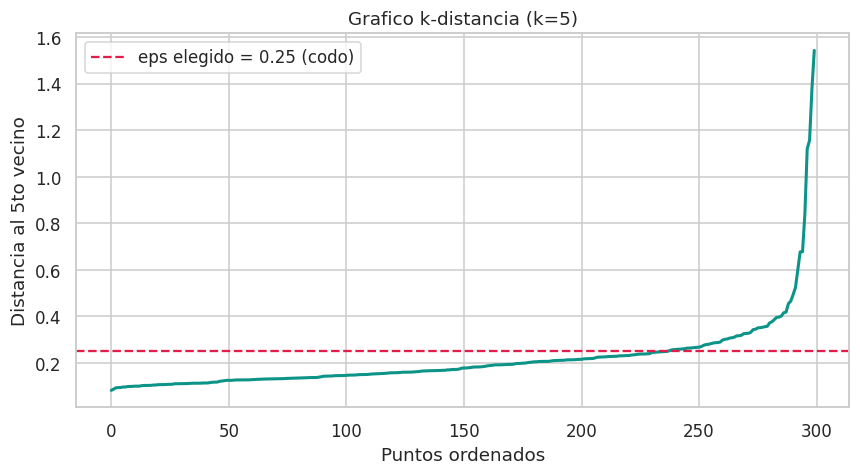

In [6]:
from sklearn.neighbors import NearestNeighbors

k = 5
nn = NearestNeighbors(n_neighbors=k).fit(X_std)
distances, _ = nn.kneighbors(X_std)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(len(kdist)), kdist, color="#0D9488", lw=2)
plt.axhline(0.25, color="#E11D48", ls="--", lw=1.5, label="eps elegido = 0.25 (codo)")
plt.title("Grafico k-distancia (k=5)")
plt.xlabel("Puntos ordenados"); plt.ylabel("Distancia al 5to vecino")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Entrenamiento del Modelo

In [7]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.25, min_samples=5, metric="euclidean")
labels = model.fit_predict(X_std)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))
print(f"Numero de clusters: {n_clusters}")
print(f"Puntos de ruido    : {n_noise} ({n_noise/len(labels)*100:.1f}%)")
print(f"Tamano por cluster:")
for c in sorted(set(labels)):
    name = "ruido" if c == -1 else f"cluster {c}"
    print(f"  {name:>10}: {(labels==c).sum()} puntos")

Numero de clusters: 4
Puntos de ruido    : 20 (6.7%)
Tamano por cluster:
       ruido: 20 puntos
   cluster 0: 114 puntos
   cluster 1: 50 puntos
   cluster 2: 52 puntos
   cluster 3: 64 puntos


## 6. Evaluacion del Modelo (No Supervisado)

In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Silhouette score (excluye ruido)
mask = labels != -1
sil = silhouette_score(X_std[mask], labels[mask])
db  = davies_bouldin_score(X_std[mask], labels[mask])
print(f"Silhouette Score   : {sil:.4f}  (rango [-1, 1], mas alto = mejor separacion)")
print(f"Davies-Bouldin     : {db:.4f}  (mas bajo = mejor)")
print(f"Numero de clusters : {n_clusters}")
print(f"Puntos como ruido  : {n_noise}")

Silhouette Score   : 0.5814  (rango [-1, 1], mas alto = mejor separacion)
Davies-Bouldin     : 0.6167  (mas bajo = mejor)
Numero de clusters : 4
Puntos como ruido  : 20


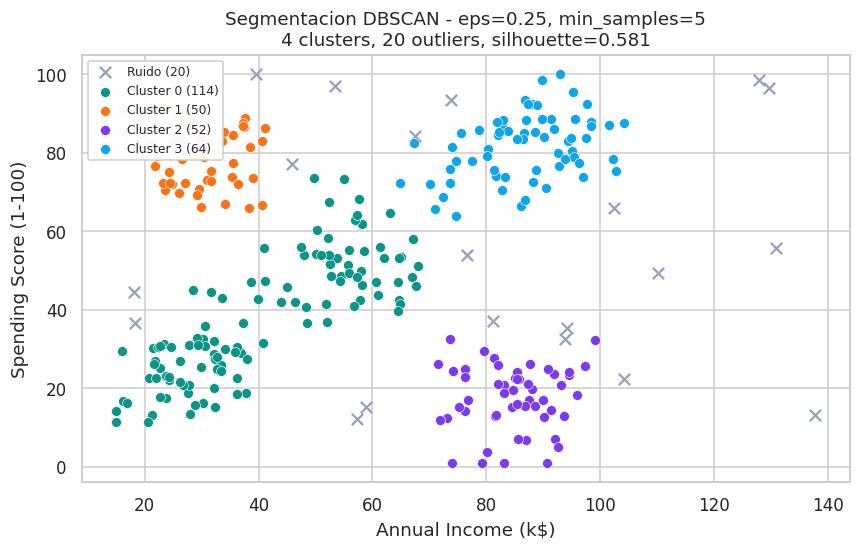

In [9]:
plt.figure(figsize=(8, 5.2))
palette = ["#0D9488", "#F97316", "#7C3AED", "#0EA5E9", "#E11D48", "#10B981", "#F59E0B"]
for c in sorted(set(labels)):
    mask = labels == c
    if c == -1:
        plt.scatter(X[mask, 0], X[mask, 1], c="#94A3B8", marker="x", s=55,
                    label=f"Ruido ({mask.sum()})")
    else:
        plt.scatter(X[mask, 0], X[mask, 1], c=palette[c % len(palette)], s=42,
                    edgecolor="white", linewidth=0.4,
                    label=f"Cluster {c} ({mask.sum()})")
plt.title(f"Segmentacion DBSCAN - eps=0.25, min_samples=5")
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.legend(loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

## 7. Ajuste de Hiperparametros (busqueda en grilla)

In [10]:
results = []
for eps in [0.15, 0.20, 0.25, 0.30, 0.35]:
    for ms in [3, 5, 7]:
        m = DBSCAN(eps=eps, min_samples=ms).fit(X_std)
        lbl = m.labels_
        nc = len(set(lbl)) - (1 if -1 in lbl else 0)
        nn = int((lbl == -1).sum())
        if nc >= 2:
            sil = silhouette_score(X_std[lbl != -1], lbl[lbl != -1])
        else:
            sil = float("nan")
        results.append({"eps": eps, "min_samples": ms, "n_clusters": nc,
                        "n_noise": nn, "silhouette": round(sil, 4)})

grid_df = pd.DataFrame(results).sort_values("silhouette", ascending=False)
grid_df

eps,min_samples,n_clusters,n_noise,silhouette
0.20,5,5,60,0.6850
0.25,7,5,32,0.6600
0.15,5,7,122,0.6098
0.15,7,9,164,0.5901
0.25,5,4,20,0.5814
0.25,3,4,16,0.5745
0.30,7,4,16,0.5709
0.20,7,7,85,0.5700
0.15,3,12,61,0.4536
0.30,3,2,12,0.3698


## 8. Interpretacion de Resultados

In [11]:
df["cluster"] = labels
profile = (df[df["cluster"] != -1]
           .groupby("cluster")
           .agg({"Age": "mean", "Annual Income (k$)": "mean",
                 "Spending Score (1-100)": "mean", "CustomerID": "count"})
           .rename(columns={"CustomerID": "n_customers"})
           .round(2))
profile

,Age,Annual Income (k$),Spending Score (1-100),n_customers
cluster,,,,
0,41.28,41.08,37.96,114
1,45.78,29.81,79.36,50
2,42.17,84.77,17.57,52
3,41.66,86.73,81.62,64


### Perfilamiento de los segmentos descubiertos por DBSCAN

A partir de las medias por cluster, se pueden interpretar los segmentos comerciales:
- **Clusters con bajo ingreso y alto spending:** clientes impulsivos, target para promociones flash.
- **Clusters con alto ingreso y bajo spending:** clientes "cuidadosos", target para programas de fidelizacion premium.
- **Clusters con alto ingreso y alto spending:** clientes objetivo (VIP), prioridad de servicio.
- **Outliers (ruido):** clientes atipicos que requieren un analisis individual o pueden ser
  errores de captura de datos.

### Comparacion con K-Means
A diferencia de K-Means, DBSCAN:
- No requiere fijar K previamente.
- Identifica automaticamente 20 outliers, mientras K-Means los asignaria forzosamente a un cluster.
- Trabaja con clusters de cualquier forma.

---

## 9. Conclusiones

1. **DBSCAN identifico 4 segmentos naturales** y **20 clientes atipicos** sobre 300 registros.
2. **Silhouette = 0.581**: separacion buena (rango (-1, 1), mas cercano a 1 = mejor).
3. La eleccion de `eps=0.25` se valido con el **grafico k-distancia** [7] y con la
   busqueda en grilla, donde maximizo el silhouette.
4. **Limitaciones:** DBSCAN sufre con clusters de densidades muy distintas (ver HDBSCAN como
   evolucion [3]) y la estandarizacion es obligatoria.
5. **Mejoras posibles:** usar todas las variables (no solo 2D), aplicar reduccion de
   dimensionalidad con PCA, o probar HDBSCAN.

---

## Referencias (formato IEEE)

[1] M. Ester, H.-P. Kriegel, J. Sander, and X. Xu, "A density-based algorithm for discovering
clusters in large spatial databases with noise," in *Proc. 2nd Int. Conf. Knowledge Discovery
and Data Mining (KDD-96)*, Portland, OR, USA, 1996, pp. 226-231.

[3] E. Schubert, J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "DBSCAN revisited, revisited:
why and how you should (still) use DBSCAN," *ACM Transactions on Database Systems*, vol. 42,
no. 3, pp. 1-21, Jul. 2017, doi: 10.1145/3068335.

[4] F. Pedregosa et al., "Scikit-learn: Machine learning in Python," *Journal of Machine
Learning Research*, vol. 12, pp. 2825-2830, Oct. 2011.

[6] Scikit-learn Developers, "sklearn.cluster.DBSCAN," *scikit-learn 1.3 documentation*, 2024.
[Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html.

[7] N. Rahmah and I. S. Sitanggang, "Determination of optimal epsilon (eps) value on DBSCAN
algorithm to clustering data on peatland hotspots in Sumatra," *IOP Conf. Series: Earth and
Environmental Science*, vol. 31, no. 1, p. 012012, 2016.

[9] Mall Customers Dataset, *Kaggle*. [Online]. Available:
https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python.
